Our data is in assignments\Assignment4\transformer_data.csv

It is "time","Y","Ta","S","I" 

It means 

• Yt: The transformer station temperature (◦C).

• Ta,t: The outdoor air temperature (◦C).

• Φs,t: The horizontal global solar radiation (W/m2) --> variable S in dataset

• ΦI,t: The load on the transformer station (kA). --> variable I in dataset


In this exercise, we shall develop models to predict the temperature evolution in transformer station
in a DSO (distribution system operator, distributing electricity from high-voltage grid out to the end
consumer) grid. Transformer stations are vital to the electricity transportation system, and having
the operate optimally is advantagous.
A brief introduction to a transformer station. Roughly speaking, a transformer station receives electricity at a high voltage and sends out electricity at a lower voltage. In this process, some energy is
lost in the transformer and converted into heat. DSO transformer stations typically use oil for cooling
(like water cooling, just with oil). The highest temperature inside the transformer station needs to be
below a given threshold in order to limit the speed of degradation of the transformer station and to
avoid it catching fire. In this data, a good approximation to this temperature is measured. We would
now like a model that is able to predict this temperature.


This is useful because we will be able to predict dangerous temperatures before they happen, and
because we will be able to relate the input (electricity load) to the output (temperature).

We want to relate the impact of I on Y


We have 7 days of hourly data, so 7*24 = 168 data points 

# 2.1

Load the provided dataset.

• Plot all four variables (Yt, Ta,t, Φs,t, ΦI,t) together in a single figure, using different colors
or panels.

• Use appropriate labels and time axes for clarity.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
fp = "C:\\Users\\leahi\\Documents\\DTU\\Time Series Analysis\\assignments\\Assignment4\\transformer_data.csv"
df = pd.read_csv(fp)

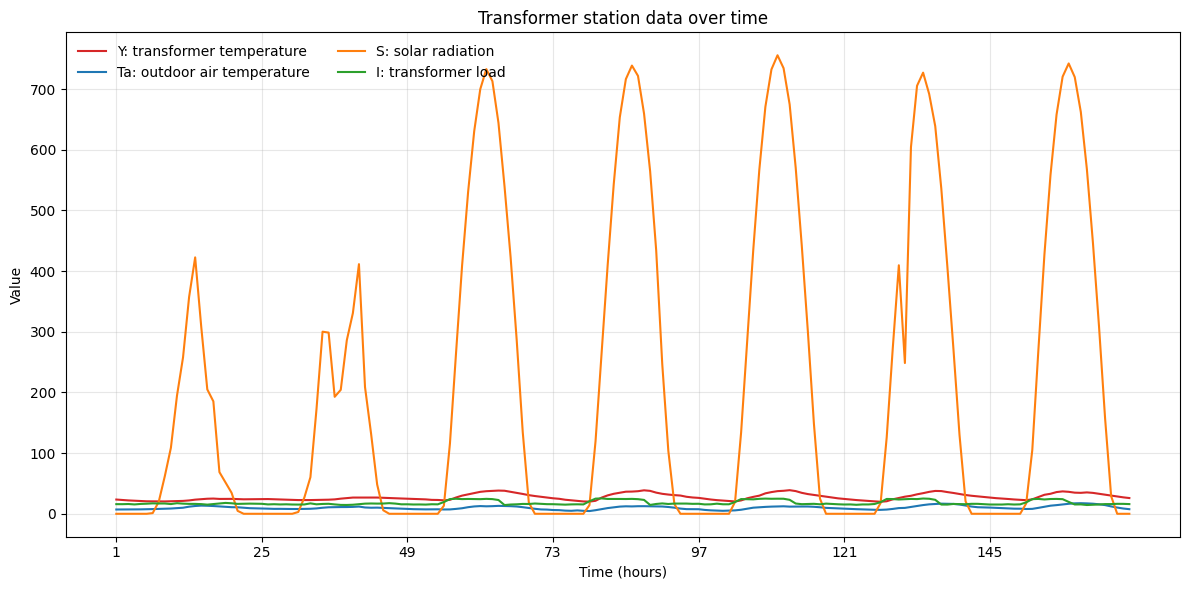

In [5]:
# Use the numeric hour `time` as x-axis
x = df["time"]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(x, df["Y"], color="tab:red", label="Y: transformer temperature")
ax.plot(x, df["Ta"], color="tab:blue", label="Ta: outdoor air temperature")
ax.plot(x, df["S"], color="tab:orange", label="S: solar radiation")
ax.plot(x, df["I"], color="tab:green", label="I: transformer load")

ax.set_xlabel("Time (hours)")
ax.set_ylabel("Value")
ax.set_title("Transformer station data over time")
ax.grid(alpha=0.3)
ax.legend(ncol=2, frameon=False)

# Optional: nicer x-ticks every 24 hours
try:
    step = 24
    xt = list(range(int(x.min()), int(x.max()) + 1, step))
    ax.set_xticks(xt)
except Exception:
    pass

plt.tight_layout()
plt.show()

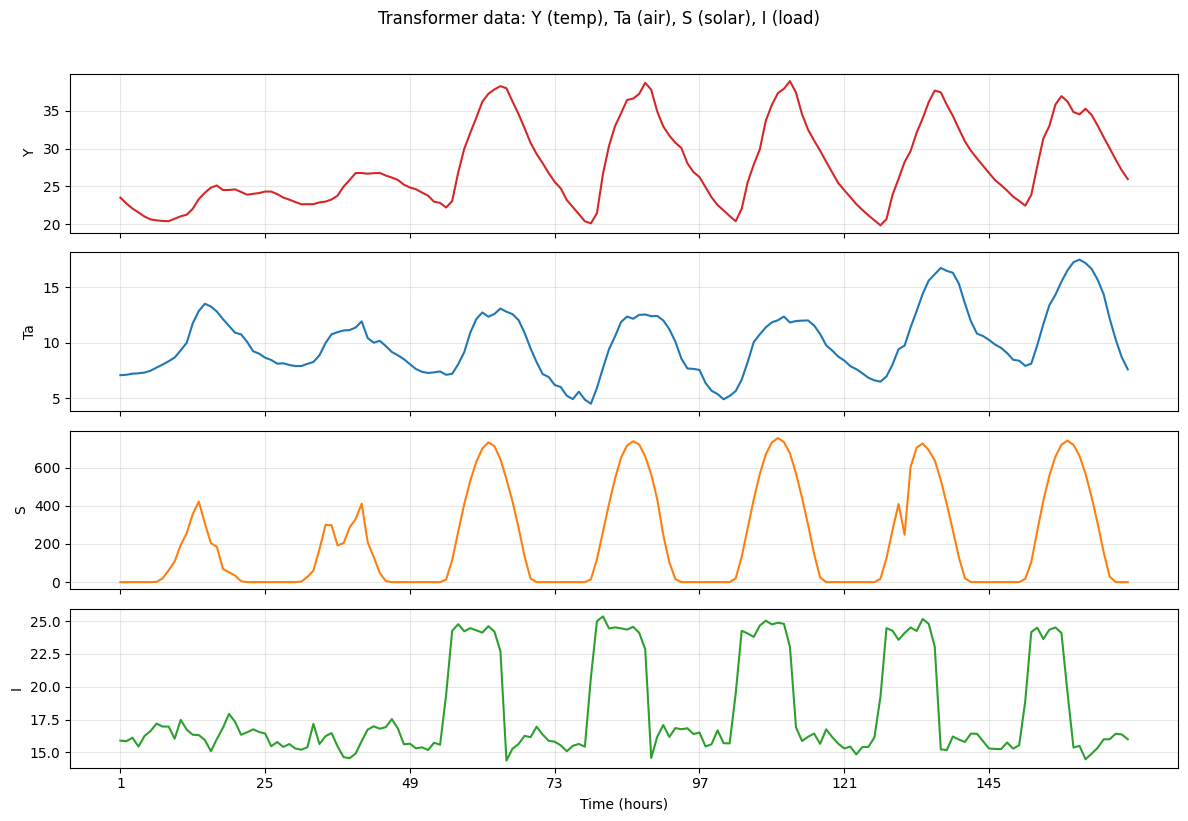

In [7]:


# Use the numeric hour `time` as x-axis
x = df["time"]

# Plot in 4 stacked panels (shared x-axis)
cols = ["Y", "Ta", "S", "I"]
colors = ["tab:red", "tab:blue", "tab:orange", "tab:green"]

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 8))
for ax, col, c in zip(axes, cols, colors):
    ax.plot(x, df[col], color=c)
    ax.set_ylabel(col)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time (hours)")
fig.suptitle("Transformer data: Y (temp), Ta (air), S (solar), I (load)", y=1.02)
plt.tight_layout()

# Optional: nicer x-ticks every 24 hours
try:
    step = 24
    xt = list(range(int(x.min()), int(x.max()) + 1, step))
    axes[-1].set_xticks(xt)
except Exception:
    pass

plt.show()

# 2.2 

In [ ]:

##############################################################

############## OLD CODE

##############################################################



import numpy as np
from scipy.optimize import minimize


# R-style implementation of the likelihood and optimizer wrapper.
# Parameter vector: [A, B_Ta, B_S, B_I, log_sigma_x, log_sigma_y]
def kf_logLik_dt(par, df):
    A = np.array([[par[0]]], dtype=float)
    B = np.array([[par[1], par[2], par[3]]], dtype=float)
    Qlt = np.array([[np.exp(par[4])]], dtype=float)
    Q = Qlt @ Qlt.T
    H = np.array([[1.0]], dtype=float)
    X0 = np.array([[df["Y"].iloc[0]]], dtype=float)
    R_obs = np.array([[np.exp(2.0 * par[5])]], dtype=float)

    obs_cols = ["Y"]
    input_cols = ["Ta", "S", "I"]

    Y = df[obs_cols].to_numpy(dtype=float)
    U = df[input_cols].to_numpy(dtype=float)
    Tn = len(df)

    n = A.shape[0]
    x_est = X0
    P_est = np.diag(np.full(n, 1e1))
    logLik = 0.0

    for t in range(Tn):
        # prediction step
        u_t = U[t].reshape(-1, 1)
        x_pred = A @ x_est + B @ u_t
        P_pred = A @ P_est @ A.T + Q

        # innovation step
        y_t = Y[t].reshape(-1, 1)
        y_pred = H @ x_pred
        S_t = H @ P_pred @ H.T + R_obs
        innov = y_t - y_pred

        # log-likelihood contribution
        logLik = logLik - 0.5 * (
            np.log(np.linalg.det(2.0 * np.pi * S_t))
            + (innov.T @ np.linalg.solve(S_t, innov))
        )

        # update step
        K_t = P_pred @ H.T @ np.linalg.solve(S_t, np.eye(S_t.shape[0]))
        x_est = x_pred + K_t @ innov
        P_est = (np.eye(n) - K_t @ H) @ P_pred

    return float(np.asarray(logLik).squeeze())


# Backward-compatible alias used elsewhere in the notebook.
kalman_loglik_dt = kf_logLik_dt


# Optimizer wrapper
# Mirrors the R function estimate_dt(start_par, df, lower=NULL, upper=NULL).
def estimate_dt(start_par, df, lower=None, upper=None):
    negLL = lambda par: -kf_logLik_dt(par, df)

    if lower is None:
        lower = np.array([0.0, -2.0, -2.0, -2.0, -8.0, -8.0], dtype=float)
    if upper is None:
        upper = np.array([1.5, 2.0, 2.0, 2.0, 3.0, 3.0], dtype=float)

    return minimize(
        fun=negLL,
        x0=np.asarray(start_par, dtype=float),
        method="L-BFGS-B",
        bounds=list(zip(lower, upper)),
        options={"maxiter": 1000, "disp": True},
    )


# Fit the model
start_par = np.array([
    0.95,
    0.05,
    0.02,
    0.05,
    np.log(0.5),
    np.log(1.0),
], dtype=float)

fit_dt = estimate_dt(start_par, df)
A_hat = np.array([[fit_dt.x[0]]], dtype=float)
B_hat = np.array([[fit_dt.x[1], fit_dt.x[2], fit_dt.x[3]]], dtype=float)
G_hat = np.array([[np.exp(fit_dt.x[4])]], dtype=float)
C_hat = np.array([[1.0]], dtype=float)
Sigma_x_hat = G_hat @ G_hat.T
Sigma_y_hat = np.array([[np.exp(2.0 * fit_dt.x[5])]], dtype=float)

print("Optimization success:", fit_dt.success)
print("Message:", fit_dt.message)
print("Log-likelihood:", kf_logLik_dt(fit_dt.x, df))
print("\nEstimated matrices:")
print("A =", A_hat)
print("B =", B_hat)
print("G =", G_hat)
print("C =", C_hat)
print("Sigma_x =", Sigma_x_hat)
print("Sigma_y =", Sigma_y_hat)

C:\Users\leahi\AppData\Local\Temp\ipykernel_36552\4275576118.py:68: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  return minimize(


Optimization success: True
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Log-likelihood: -165.5069222650539

Estimated matrices:
A = [[0.80098417]]
B = [[0.10199939 0.00287436 0.21342742]]
G = [[0.64439817]]
C = [[1.]]
Sigma_x = [[0.415249]]
Sigma_y = [[1.12535175e-07]]


In [3]:
import numpy as np
from scipy.optimize import minimize


def kf_logLik_dt(par, df):
    A = np.array([[par[0]]], dtype=float)
    B = np.array([[par[1], par[2], par[3]]], dtype=float)

    G = np.array([[np.exp(par[4])]], dtype=float)
    Q = G @ G.T

    H = np.array([[1.0]], dtype=float)
    R_obs = np.array([[np.exp(2.0 * par[5])]], dtype=float)

    obs_cols = ["Y"]
    input_cols = ["Ta", "S", "I"]

    Y = df[obs_cols].to_numpy(dtype=float)
    U = df[input_cols].to_numpy(dtype=float)
    Tn = len(df)

    n = A.shape[0]

    # Condition on first observation as initial state
    x_est = np.array([[Y[0, 0]]], dtype=float)
    P_est = np.diag(np.full(n, 1e1))

    logLik = 0.0

    # Start at t = 1 because Y[0] was used as initial state
    for t in range(1, Tn):
        # Predict X_t from X_{t-1} and u_{t-1}
        u_prev = U[t - 1].reshape(-1, 1)

        x_pred = A @ x_est + B @ u_prev
        P_pred = A @ P_est @ A.T + Q

        # Innovation using Y_t
        y_t = Y[t].reshape(-1, 1)
        y_pred = H @ x_pred
        S_t = H @ P_pred @ H.T + R_obs
        innov = y_t - y_pred

        logLik += -0.5 * (
            np.log(np.linalg.det(2.0 * np.pi * S_t))
            + innov.T @ np.linalg.solve(S_t, innov)
        ).item()

        # Kalman update
        K_t = P_pred @ H.T @ np.linalg.solve(S_t, np.eye(S_t.shape[0]))
        x_est = x_pred + K_t @ innov
        P_est = (np.eye(n) - K_t @ H) @ P_pred

    return float(logLik)


# Backward-compatible alias used elsewhere in the notebook.
kalman_loglik_dt = kf_logLik_dt


# Optimizer wrapper
# Mirrors the R function estimate_dt(start_par, df, lower=NULL, upper=NULL).
def estimate_dt(start_par, df, lower=None, upper=None):
    negLL = lambda par: -kf_logLik_dt(par, df)

    if lower is None:
        lower = np.array([0.0, -2.0, -2.0, -2.0, -8.0, -8.0], dtype=float)
    if upper is None:
        upper = np.array([1.5, 2.0, 2.0, 2.0, 3.0, 3.0], dtype=float)

    return minimize(
        fun=negLL,
        x0=np.asarray(start_par, dtype=float),
        method="L-BFGS-B",
        bounds=list(zip(lower, upper)),
        options={"maxiter": 1000, "disp": True},
    )


# Fit the model
start_par = np.array([
    0.95,
    0.05,
    0.02,
    0.05,
    np.log(0.5),
    np.log(1.0),
], dtype=float)

fit_dt = estimate_dt(start_par, df)
A_hat = np.array([[fit_dt.x[0]]], dtype=float)
B_hat = np.array([[fit_dt.x[1], fit_dt.x[2], fit_dt.x[3]]], dtype=float)
G_hat = np.array([[np.exp(fit_dt.x[4])]], dtype=float)
C_hat = np.array([[1.0]], dtype=float)
Sigma_x_hat = G_hat @ G_hat.T
Sigma_y_hat = np.array([[np.exp(2.0 * fit_dt.x[5])]], dtype=float)

print("Optimization success:", fit_dt.success)
print("Message:", fit_dt.message)
print("Log-likelihood:", kf_logLik_dt(fit_dt.x, df))
print("\nEstimated matrices:")
print("A =", A_hat)
print("B =", B_hat)
print("G =", G_hat)
print("C =", C_hat)
print("Sigma_x =", Sigma_x_hat)
print("Sigma_y =", Sigma_y_hat)

C:\Users\leahi\AppData\Local\Temp\ipykernel_34052\1596416768.py:71: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  return minimize(


Optimization success: True
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Log-likelihood: -153.9937282346416

Estimated matrices:
A = [[0.73511813]]
B = [[0.11152459 0.00232134 0.31531588]]
G = [[0.60511711]]
C = [[1.]]
Sigma_x = [[0.36616671]]
Sigma_y = [[1.12535175e-07]]


Estimated parameters:
Parameter     Estimate
        A 7.351181e-01
     B_Ta 1.115246e-01
      B_S 2.321338e-03
      B_I 3.153159e-01
        G 6.051171e-01
  Sigma_x 3.661667e-01
  Sigma_y 1.125352e-07

Log-likelihood: -153.994
AIC: 319.987
BIC: 338.695

Residual mean: -0.0149
Residual std:  0.6057


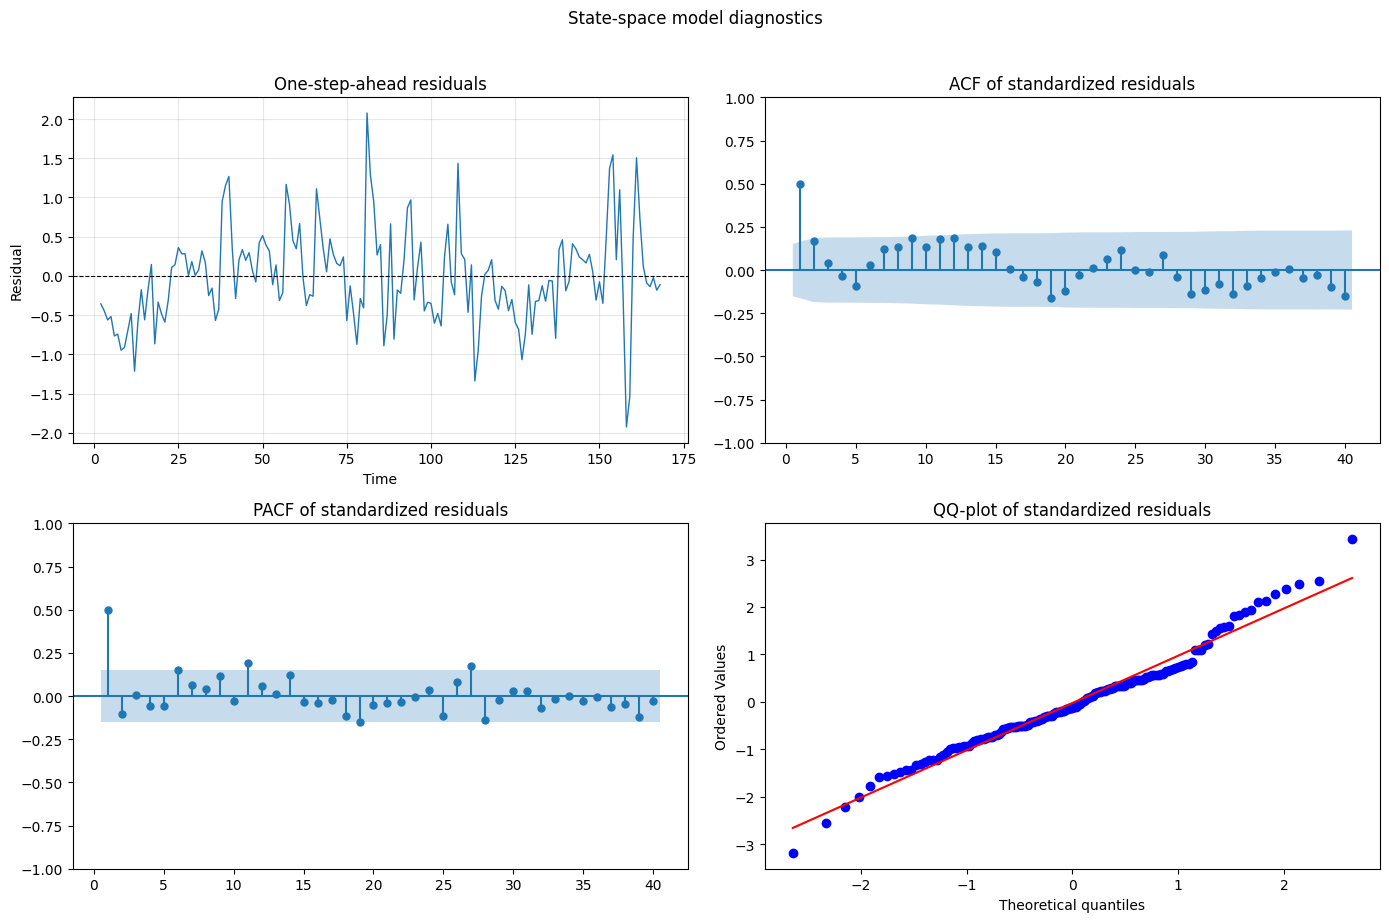

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.stats import probplot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf




# ============================================================
# Kalman filter diagnostics
# ============================================================

def kf_diagnostics_dt(par, df):
    A = np.array([[par[0]]], dtype=float)
    B = np.array([[par[1], par[2], par[3]]], dtype=float)

    G = np.array([[np.exp(par[4])]], dtype=float)
    Q = G @ G.T

    H = np.array([[1.0]], dtype=float)
    R_obs = np.array([[np.exp(2.0 * par[5])]], dtype=float)

    Y = df[["Y"]].to_numpy(dtype=float)
    U = df[["Ta", "S", "I"]].to_numpy(dtype=float)
    Tn = len(df)

    x_est = np.array([[Y[0, 0]]], dtype=float)
    P_est = np.diag(np.full(A.shape[0], 1e1))

    predictions = np.full(Tn, np.nan, dtype=float)
    residuals = np.full(Tn, np.nan, dtype=float)
    standardized_residuals = np.full(Tn, np.nan, dtype=float)

    # Start from t = 1 because Y[0] initializes the state
    for t in range(1, Tn):
        # Predict X_t from X_{t-1} and u_{t-1}
        u_prev = U[t - 1].reshape(-1, 1)

        x_pred = A @ x_est + B @ u_prev
        P_pred = A @ P_est @ A.T + Q

        y_pred = H @ x_pred
        S_t = H @ P_pred @ H.T + R_obs
        innov = Y[t].reshape(-1, 1) - y_pred

        s_scalar = float(np.asarray(S_t).squeeze())
        residual_scalar = float(np.asarray(innov).squeeze())

        predictions[t] = float(np.asarray(y_pred).squeeze())
        residuals[t] = residual_scalar
        standardized_residuals[t] = residual_scalar / np.sqrt(s_scalar)

        K_t = P_pred @ H.T @ np.linalg.solve(S_t, np.eye(S_t.shape[0]))
        x_est = x_pred + K_t @ innov
        P_est = (np.eye(A.shape[0]) - K_t @ H) @ P_pred

    return predictions, residuals, standardized_residuals


# Run diagnostics
predictions_dt, residuals_dt, std_residuals_dt = kf_diagnostics_dt(fit_dt.x, df)

valid = ~np.isnan(std_residuals_dt)
resid_valid = residuals_dt[valid]
std_resid_valid = std_residuals_dt[valid]

ll_dt = kf_logLik_dt(fit_dt.x, df)
k_dt = len(fit_dt.x)
n_dt = valid.sum()

aic_dt = 2 * k_dt - 2 * ll_dt
bic_dt = np.log(n_dt) * k_dt - 2 * ll_dt

params_df = pd.DataFrame(
    [
        ["A", A_hat[0, 0]],
        ["B_Ta", B_hat[0, 0]],
        ["B_S", B_hat[0, 1]],
        ["B_I", B_hat[0, 2]],
        ["G", G_hat[0, 0]],
        ["Sigma_x", Sigma_x_hat[0, 0]],
        ["Sigma_y", Sigma_y_hat[0, 0]],
    ],
    columns=["Parameter", "Estimate"],
)

print("Estimated parameters:")
print(params_df.to_string(index=False))
print()
print(f"Log-likelihood: {ll_dt:.3f}")
print(f"AIC: {aic_dt:.3f}")
print(f"BIC: {bic_dt:.3f}")
print()
print(f"Residual mean: {resid_valid.mean():.4f}")
print(f"Residual std:  {resid_valid.std(ddof=1):.4f}")


# ============================================================
# Diagnostic plots
# ============================================================

lag_limit = min(40, max(1, len(std_resid_valid) // 2 - 1))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

x_axis = df["time"] if "time" in df.columns else np.arange(len(df))

axes[0, 0].plot(x_axis, residuals_dt, color="tab:blue", linewidth=1)
axes[0, 0].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[0, 0].set_title("One-step-ahead residuals")
axes[0, 0].set_xlabel("Time")
axes[0, 0].set_ylabel("Residual")
axes[0, 0].grid(alpha=0.3)

plot_acf(std_resid_valid, lags=lag_limit, ax=axes[0, 1], zero=False)
axes[0, 1].set_title("ACF of standardized residuals")

plot_pacf(std_resid_valid, lags=lag_limit, ax=axes[1, 0], zero=False, method="ywm")
axes[1, 0].set_title("PACF of standardized residuals")

probplot(std_resid_valid, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("QQ-plot of standardized residuals")

plt.suptitle("State-space model diagnostics", y=1.02)
plt.tight_layout()
plt.show()

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Recompute one-step-ahead predictions and prediction variances using fitted parameters
par = fit_dt.x

A = np.array([[par[0]]], dtype=float)
B = np.array([[par[1], par[2], par[3]]], dtype=float)

G = np.array([[np.exp(par[4])]], dtype=float)
Q = G @ G.T

H = np.array([[1.0]], dtype=float)
R_obs = np.array([[np.exp(2.0 * par[5])]], dtype=float)

Y = df["Y"].to_numpy(dtype=float)
U = df[["Ta", "S", "I"]].to_numpy(dtype=float)
Tn = len(df)

# Initial state from first observation
x_est = np.array([[Y[0]]], dtype=float)
P_est = np.diag(np.full(A.shape[0], 1e1))

pred_mean = np.full(Tn, np.nan, dtype=float)
pred_var = np.full(Tn, np.nan, dtype=float)

# Start at t = 1 because Y[0] initializes the state
for t in range(1, Tn):
    # Predict X_t using X_{t-1} and u_{t-1}
    u_prev = U[t - 1].reshape(-1, 1)

    x_pred = A @ x_est + B @ u_prev
    P_pred = A @ P_est @ A.T + Q

    # One-step-ahead prediction of Y_t
    y_pred = H @ x_pred
    S_t = H @ P_pred @ H.T + R_obs

    pred_mean[t] = float(np.asarray(y_pred).squeeze())
    pred_var[t] = float(np.asarray(S_t).squeeze())

    # Innovation and update
    innov = np.array([[Y[t]]], dtype=float) - y_pred

    K_t = P_pred @ H.T @ np.linalg.solve(S_t, np.eye(S_t.shape[0]))
    x_est = x_pred + K_t @ innov
    P_est = (np.eye(A.shape[0]) - K_t @ H) @ P_pred

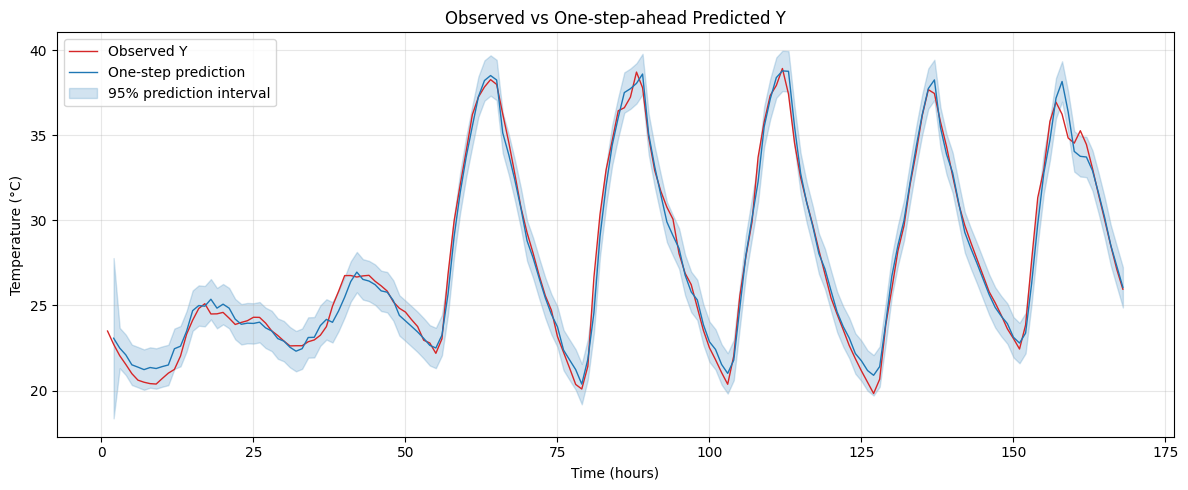

In [7]:
valid = ~np.isnan(pred_mean)

# Observed vs Predicted with 95% prediction interval
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df["time"], Y, label="Observed Y", color="tab:red", linewidth=1)
ax.plot(df["time"], pred_mean, label="One-step prediction", color="tab:blue", linewidth=1)

ci = 1.96 * np.sqrt(pred_var)

ax.fill_between(
    df["time"],
    pred_mean - ci,
    pred_mean + ci,
    color="tab:blue",
    alpha=0.2,
    label="95% prediction interval",
)

ax.set_xlabel("Time (hours)")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Observed vs One-step-ahead Predicted Y")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

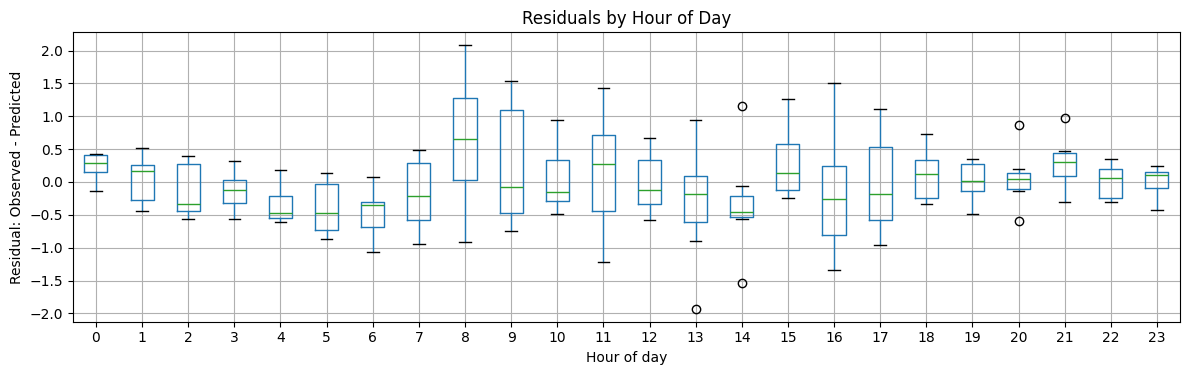

In [8]:
residuals = Y - pred_mean

df_res = pd.DataFrame({
    "time": df["time"],
    "residual": residuals,
})

df_res = df_res.dropna()

# If time is measured in hours starting at 1, this is okay:
df_res["hour"] = ((df_res["time"] - 1) % 24).astype(int)

fig, ax = plt.subplots(figsize=(12, 4))

df_res.boxplot(column="residual", by="hour", ax=ax)

ax.set_title("Residuals by Hour of Day")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Residual: Observed - Predicted")

plt.suptitle("")
plt.tight_layout()
plt.show()

Per-hour residual summary:
 hour      mean      std  count  outliers
    0  0.236459 0.217294      6         0
    1  0.030820 0.361717      7         0
    2 -0.119861 0.416359      7         0
    3 -0.137020 0.293955      7         0
    4 -0.346915 0.291120      7         0
    5 -0.389329 0.409042      7         0
    6 -0.474735 0.371742      7         0
    7 -0.180995 0.551015      7         0
    8  0.631575 1.006317      7         0
    9  0.281997 0.951120      7         0
   10  0.057259 0.505170      7         0
   11  0.150192 0.930661      7         0
   12 -0.001725 0.459928      7         0
   13 -0.310946 0.904475      7         1
   14 -0.334609 0.798882      7         2
   15  0.297173 0.544315      7         0
   16 -0.170782 0.944397      7         0
   17 -0.014318 0.782537      7         0
   18  0.101064 0.397188      7         0
   19  0.021747 0.303395      7         0
   20  0.057134 0.437375      7         2
   21  0.288881 0.402854      7         1
   22 -

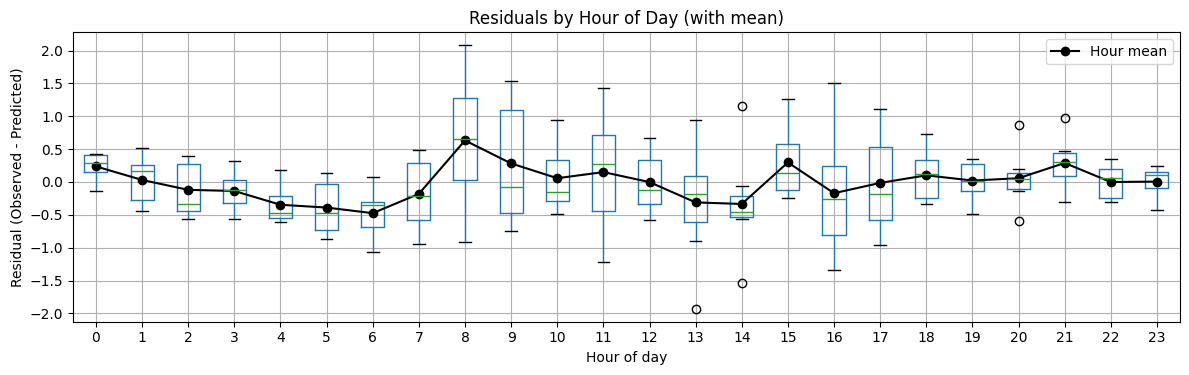

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure one-step predictions exist; recompute if necessary
try:
    pred_mean
except NameError:
    par = fit_dt.x
    A = np.array([[par[0]]], dtype=float)
    B = np.array([[par[1], par[2], par[3]]], dtype=float)
    Qlt = np.array([[np.exp(par[4])]], dtype=float)
    Q = Qlt @ Qlt.T
    H = np.array([[1.0]], dtype=float)
    R_obs = np.array([[np.exp(2.0 * par[5])]], dtype=float)
    Y = df['Y'].to_numpy(dtype=float)
    U = df[['Ta', 'S', 'I']].to_numpy(dtype=float)
    x_est = np.array([[Y[0]]], dtype=float)
    P_est = np.diag(np.full(A.shape[0], 1e1))
    pred_mean = np.zeros(len(df))
    pred_var = np.zeros(len(df))
    for t in range(len(df)):
        u_t = U[t].reshape(-1, 1)
        x_pred = A @ x_est + B @ u_t
        P_pred = A @ P_est @ A.T + Q
        y_pred = H @ x_pred
        S_t = H @ P_pred @ H.T + R_obs
        pred_mean[t] = float(np.asarray(y_pred).squeeze())
        pred_var[t] = float(np.asarray(S_t).squeeze())
        innov = np.array([[Y[t]]]) - y_pred
        K_t = P_pred @ H.T @ np.linalg.solve(S_t, np.eye(S_t.shape[0]))
        x_est = x_pred + K_t @ innov
        P_est = (np.eye(A.shape[0]) - K_t @ H) @ P_pred

# residuals and hour
residuals = df['Y'].to_numpy(dtype=float) - pred_mean
hour = ((df['time'] - 1) % 24).astype(int)
df_res = pd.DataFrame({'hour': hour, 'residual': residuals})

# per-hour statistics
group = df_res.groupby('hour')['residual']
mean = group.mean()
std = group.std()
count = group.count()

def outlier_count(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    return int(((s < (q1 - 1.5 * iqr)) | (s > (q3 + 1.5 * iqr))).sum())

outliers = group.apply(outlier_count)

stats = pd.DataFrame({'hour': mean.index, 'mean': mean.values, 'std': std.values, 'count': count.values, 'outliers': outliers.values})

print('Per-hour residual summary:')
print(stats.to_string(index=False))

# Boxplot with mean overlay
fig, ax = plt.subplots(figsize=(12, 4))
df_res.boxplot(column='residual', by='hour', ax=ax)
ax.plot(np.arange(1, 25), stats['mean'], marker='o', color='black', label='Hour mean')
ax.set_title('Residuals by Hour of Day (with mean)')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Residual (Observed - Predicted)')
ax.legend()
plt.suptitle('')
plt.tight_layout()
plt.show()

“Does the model capture the temperature dynamics satisfactorily?”

Yes if: the observed vs predicted lines track closely, residual mean ≈ 0, standardized residuals look white (no significant ACF), QQ-plot close to diagonal, no strong dependence of residuals on inputs or hour, and rolling RMSE stays small relative to typical temperature swings.
No if: you see systematic bias (predictions lag or under/overshoot peaks), significant autocorrelation in residuals, large standardized residuals (heavy tails), or strong dependence of residual size on time-of-day or inputs.
“Are there periods where the model performs poorly (e.g., daytime peaks)?”

Use the Residuals by Hour boxplot and Rolling RMSE first. If these show larger spread or higher RMSE during daytime hours, the model underfits daytime heating effects.
Confirm with Observed vs Predicted over a representative day/week: missed daytime peaks will be visually obvious.
If residuals correlate with S (solar) or I (load) in the residuals-vs-input scatter, that points to missing nonlinear or lagged input effects around peak times.





Report analysis : 

This summary says the model is not uniformly capturing the daily dynamics. It looks reasonably good in some hours, but there are clear time-of-day patterns in the residuals, which means the model is missing something systematic.

What stands out:

Hours 6–7: mean residuals are clearly negative, around -0.86 and -0.65. That means the model is, on average, overpredicting temperature there.
Hours 8–9: mean residuals turn strongly positive, especially at hour 8. That means the model is then underpredicting temperature during the morning rise.
Hours 13–14: negative again, so it overpredicts around early afternoon.
Hour 16: positive again, so it underpredicts later in the day.
Hours 17–18: negative again.
That alternating sign pattern is important. It suggests the model is not just noisy, but systematically lagging or smoothing the daily temperature cycle. In other words, it does not fully capture the daytime peak / ramp-up / ramp-down behavior.

About the spread:

The largest standard deviations appear around hours 8, 9, 11, 13, 14, 16, 17.
Those are exactly the periods where daytime dynamics are strongest.
So the model seems to perform worst during transition periods and daytime peaks, which matches your suspicion.
About outliers:

There are only a few outliers, so the model is not producing lots of extreme residuals.
But the important issue is not just outliers; it is the hourly bias pattern.

# 2.3

Expand to a 2-dimensional latent state model with an estimated initial state `X0` and fixed observation mapping `C = [1, 0]`.


About the estimated initial statae X0 : 


In [12]:
import numpy as np
from scipy.optimize import minimize


import numpy as np
from scipy.optimize import minimize


# 2D latent-state model.
# Parameter vector:
# [A11, A12, A21, A22,
#  B11, B12, B13, B21, B22, B23,
#  log_g11, g21, log_g22,
#  x01, x02,
#  log_sigma_y]
#
# C is fixed to [1, 0] and X0 is estimated.
def kf_logLik_dt_2d(par, df):
    A = np.array(
        [
            [par[0], par[1]],
            [par[2], par[3]],
        ],
        dtype=float,
    )

    B = np.array(
        [
            [par[4], par[5], par[6]],
            [par[7], par[8], par[9]],
        ],
        dtype=float,
    )

    # Lower-triangular noise scaling matrix G
    G = np.array(
        [
            [np.exp(par[10]), 0.0],
            [par[11], np.exp(par[12])],
        ],
        dtype=float,
    )

    Q = G @ G.T

    C = np.array([[1.0, 0.0]], dtype=float)

    X0 = np.array(
        [
            [par[13]],
            [par[14]],
        ],
        dtype=float,
    )

    R_obs = np.array([[np.exp(2.0 * par[15])]], dtype=float)

    Y = df[["Y"]].to_numpy(dtype=float)
    U = df[["Ta", "S", "I"]].to_numpy(dtype=float)
    Tn = len(df)

    x_est = X0
    P_est = np.diag([10.0, 10.0])

    logLik = 0.0

    # Start at t = 1 because X0 represents the latent state at time 0
    for t in range(1, Tn):
        # Predict X_t using X_{t-1} and u_{t-1}
        u_prev = U[t - 1].reshape(-1, 1)

        x_pred = A @ x_est + B @ u_prev
        P_pred = A @ P_est @ A.T + Q

        # Observation prediction
        y_t = Y[t].reshape(-1, 1)
        y_pred = C @ x_pred
        S_t = C @ P_pred @ C.T + R_obs
        innov = y_t - y_pred

        S_scalar = float(np.asarray(S_t).squeeze())
        innov_scalar = float(np.asarray(innov).squeeze())

        logLik += -0.5 * (
            np.log(2.0 * np.pi * S_scalar)
            + (innov_scalar**2) / S_scalar
        )

        # Kalman update
        K_t = P_pred @ C.T @ np.linalg.solve(S_t, np.eye(S_t.shape[0]))
        x_est = x_pred + K_t @ innov
        P_est = (np.eye(2) - K_t @ C) @ P_pred

    return float(logLik)


def estimate_dt_2d(start_par, df, lower=None, upper=None):
    negLL = lambda par: -kf_logLik_dt_2d(par, df)

    if lower is None:
        lower = np.array([
            0.0, -2.0,
            -2.0, 0.0,
            -2.0, -2.0, -2.0,
            -2.0, -2.0, -2.0,
            -8.0, -5.0, -8.0,
            -20.0, -20.0,
            -8.0,
        ], dtype=float)
    if upper is None:
        upper = np.array([
            1.5, 2.0,
            2.0, 1.5,
            2.0, 2.0, 2.0,
            2.0, 2.0, 2.0,
            3.0, 5.0, 3.0,
            40.0, 40.0,
            3.0,
        ], dtype=float)

    return minimize(
        fun=negLL,
        x0=np.asarray(start_par, dtype=float),
        method="L-BFGS-B",
        bounds=list(zip(lower, upper)),
        options={"maxiter": 2000, "disp": True},
    )


start_par_2d = np.array([
    0.90, 0.05,
    0.00, 0.95,
    0.05, 0.01, 0.02,
    0.01, 0.05, 0.02,
    np.log(0.5), 0.0, np.log(0.3),
    df["Y"].iloc[0], 0.0,
    np.log(1.0),
], dtype=float)

fit_dt_2d = estimate_dt_2d(start_par_2d, df)

par2 = fit_dt_2d.x
A2_hat = np.array([[par2[0], par2[1]],
                   [par2[2], par2[3]]], dtype=float)
B2_hat = np.array([[par2[4], par2[5], par2[6]],
                   [par2[7], par2[8], par2[9]]], dtype=float)
G2_hat = np.array([[np.exp(par2[10]), 0.0],
                   [par2[11], np.exp(par2[12])]], dtype=float)
C2_hat = np.array([[1.0, 0.0]], dtype=float)
X0_2_hat = np.array([[par2[13]],
                     [par2[14]]], dtype=float)
Sigma_x_2_hat = G2_hat @ G2_hat.T
Sigma_y_2_hat = np.array([[np.exp(2.0 * par2[15])]], dtype=float)

print("Optimization success:", fit_dt_2d.success)
print("Message:", fit_dt_2d.message)
print("Log-likelihood:", kf_logLik_dt_2d(par2, df))
print("\nEstimated matrices:")
print("A =\n", A2_hat)
print("B =\n", B2_hat)
print("G =\n", G2_hat)
print("C =\n", C2_hat)
print("X0 =\n", X0_2_hat)
print("Sigma_x =\n", Sigma_x_2_hat)
print("Sigma_y =\n", Sigma_y_2_hat)

C:\Users\leahi\AppData\Local\Temp\ipykernel_34052\420489135.py:121: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  return minimize(


Optimization success: True
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Log-likelihood: -128.51742359878517

Estimated matrices:
A =
 [[0.66195012 0.06306673]
 [0.32547126 0.4675781 ]]
B =
 [[ 0.22016052  0.00170741  0.32354211]
 [-0.60157269  0.0039746   0.21623861]]
G =
 [[0.51788065 0.        ]
 [4.9987626  0.26713372]]
C =
 [[1. 0.]]
X0 =
 [[23.76979594]
 [-2.9673487 ]]
Sigma_x =
 [[ 0.26820036  2.5887624 ]
 [ 2.5887624  25.05898797]]
Sigma_y =
 [[0.00022747]]


DOUBLE CHECK : 

- @Loic : used C=[1 0] or C=[1 1] 



Log-likelihood: -128.517
AIC: 289.035
BIC: 338.923
Residual mean: -0.0020
Residual std:  0.5202


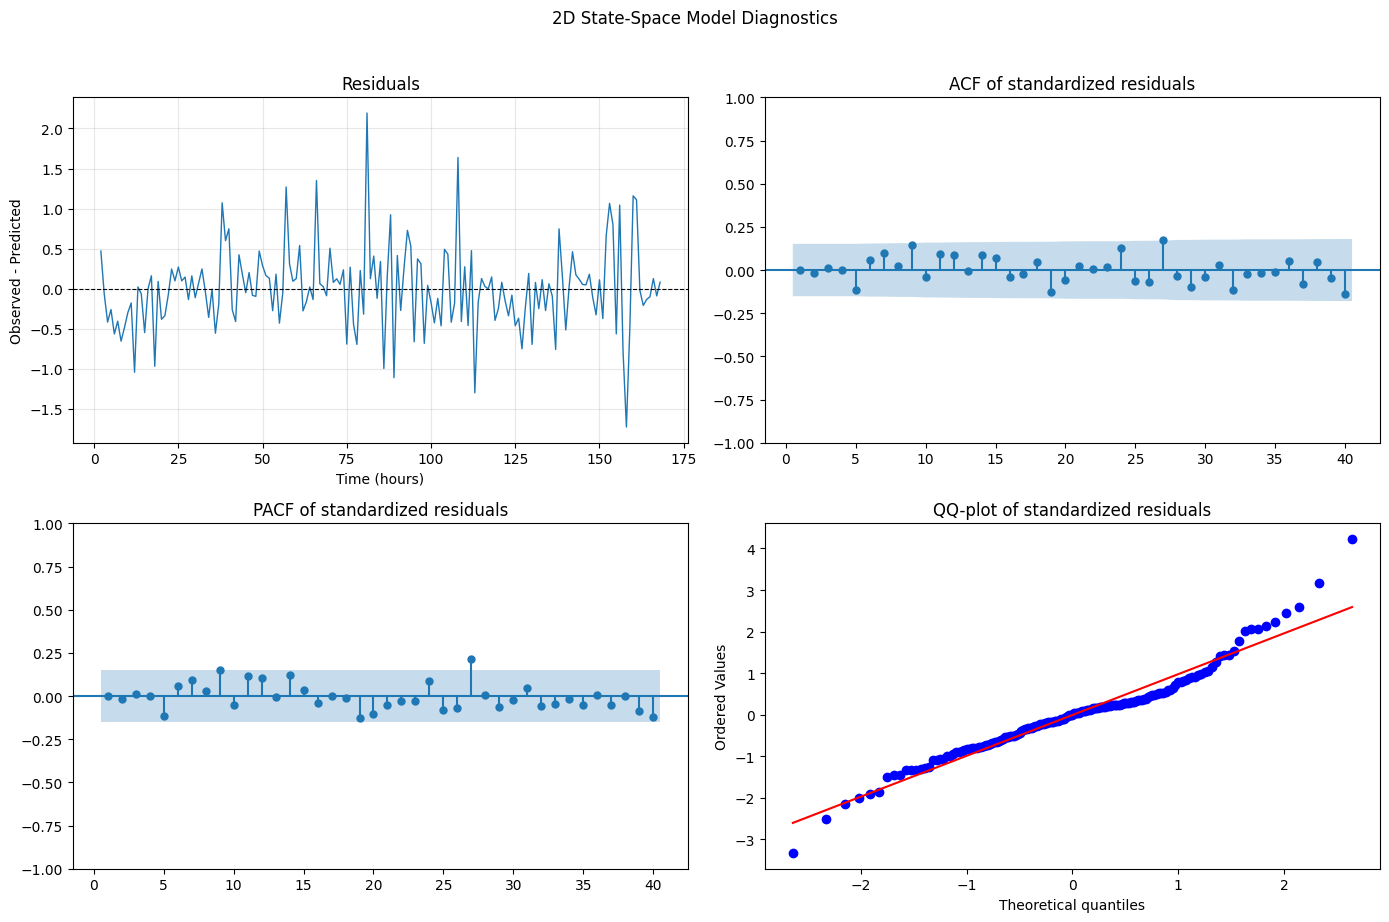

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import probplot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# Residual analysis for the 2D model with C = [1, 0]

par2 = fit_dt_2d.x

A = np.array(
    [
        [par2[0], par2[1]],
        [par2[2], par2[3]],
    ],
    dtype=float,
)

B = np.array(
    [
        [par2[4], par2[5], par2[6]],
        [par2[7], par2[8], par2[9]],
    ],
    dtype=float,
)

G = np.array(
    [
        [np.exp(par2[10]), 0.0],
        [par2[11], np.exp(par2[12])],
    ],
    dtype=float,
)

Q = G @ G.T

C = np.array([[1.0, 0.0]], dtype=float)

X0 = np.array(
    [
        [par2[13]],
        [par2[14]],
    ],
    dtype=float,
)

R_obs = np.array([[np.exp(2.0 * par2[15])]], dtype=float)

Y = df[["Y"]].to_numpy(dtype=float)
U = df[["Ta", "S", "I"]].to_numpy(dtype=float)
Tn = len(df)

x_est = X0
P_est = np.diag([10.0, 10.0])

pred_mean = np.full(Tn, np.nan, dtype=float)
pred_var = np.full(Tn, np.nan, dtype=float)
residuals_2d = np.full(Tn, np.nan, dtype=float)
std_residuals_2d = np.full(Tn, np.nan, dtype=float)

# Start at t = 1 because X0 is the state at time 0
for t in range(1, Tn):
    # Predict X_t using X_{t-1} and u_{t-1}
    u_prev = U[t - 1].reshape(-1, 1)

    x_pred = A @ x_est + B @ u_prev
    P_pred = A @ P_est @ A.T + Q

    # Predict observation Y_t
    y_pred = C @ x_pred
    S_t = C @ P_pred @ C.T + R_obs
    innov = Y[t].reshape(-1, 1) - y_pred

    pred_mean[t] = float(np.asarray(y_pred).squeeze())
    pred_var[t] = float(np.asarray(S_t).squeeze())
    residuals_2d[t] = float(np.asarray(innov).squeeze())
    std_residuals_2d[t] = residuals_2d[t] / np.sqrt(pred_var[t])

    # Kalman update
    K_t = P_pred @ C.T @ np.linalg.solve(S_t, np.eye(S_t.shape[0]))
    x_est = x_pred + K_t @ innov
    P_est = (np.eye(2) - K_t @ C) @ P_pred









valid = ~np.isnan(std_residuals_2d)

resid_valid_2d = residuals_2d[valid]
std_resid_valid_2d = std_residuals_2d[valid]

ll_2d = kf_logLik_dt_2d(par2, df)
k_2d = len(par2)
n_2d = valid.sum()

aic_2d = 2 * k_2d - 2 * ll_2d
bic_2d = np.log(n_2d) * k_2d - 2 * ll_2d

print(f"Log-likelihood: {ll_2d:.3f}")
print(f"AIC: {aic_2d:.3f}")
print(f"BIC: {bic_2d:.3f}")
print(f"Residual mean: {resid_valid_2d.mean():.4f}")
print(f"Residual std:  {resid_valid_2d.std(ddof=1):.4f}")



lag_limit = min(40, max(1, len(std_resid_valid_2d) // 2 - 1))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(df["time"], residuals_2d, color="tab:blue", linewidth=1)
axes[0, 0].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[0, 0].set_title("Residuals")
axes[0, 0].set_xlabel("Time (hours)")
axes[0, 0].set_ylabel("Observed - Predicted")
axes[0, 0].grid(alpha=0.3)

plot_acf(std_resid_valid_2d, lags=lag_limit, ax=axes[0, 1], zero=False)
axes[0, 1].set_title("ACF of standardized residuals")

plot_pacf(std_resid_valid_2d, lags=lag_limit, ax=axes[1, 0], zero=False, method="ywm")
axes[1, 0].set_title("PACF of standardized residuals")

probplot(std_resid_valid_2d, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("QQ-plot of standardized residuals")

plt.suptitle("2D State-Space Model Diagnostics", y=1.02)
plt.tight_layout()
plt.show()

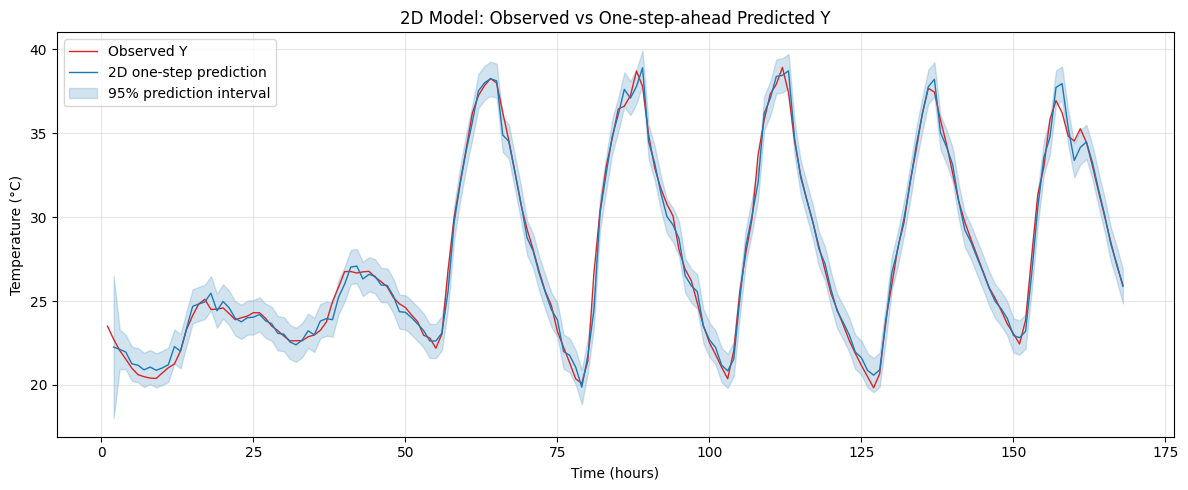

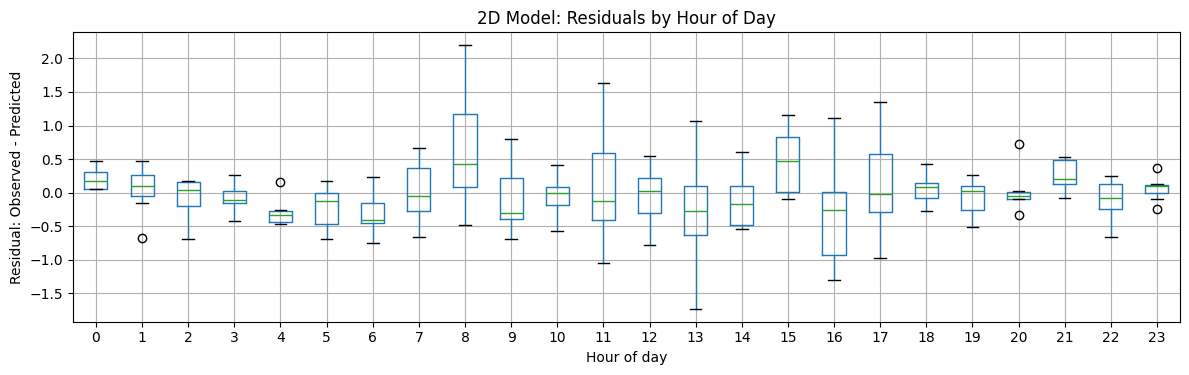

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# One-step-ahead prediction plot and residual-by-hour boxplot for 2D model
# Model:
#   X_{t+1} = A X_t + B u_t + G e_{1,t}
#   Y_t     = C X_t + e_{2,t}

par2 = fit_dt_2d.x

A = np.array(
    [
        [par2[0], par2[1]],
        [par2[2], par2[3]],
    ],
    dtype=float,
)

B = np.array(
    [
        [par2[4], par2[5], par2[6]],
        [par2[7], par2[8], par2[9]],
    ],
    dtype=float,
)

G = np.array(
    [
        [np.exp(par2[10]), 0.0],
        [par2[11], np.exp(par2[12])],
    ],
    dtype=float,
)

Q = G @ G.T

C = np.array([[1.0, 0.0]], dtype=float)

X0 = np.array(
    [
        [par2[13]],
        [par2[14]],
    ],
    dtype=float,
)

R_obs = np.array([[np.exp(2.0 * par2[15])]], dtype=float)

Y = df[["Y"]].to_numpy(dtype=float)
U = df[["Ta", "S", "I"]].to_numpy(dtype=float)
Tn = len(df)

x_est = X0
P_est = np.diag([10.0, 10.0])

pred_mean_2d = np.full(Tn, np.nan, dtype=float)
pred_var_2d = np.full(Tn, np.nan, dtype=float)
residuals_for_box = np.full(Tn, np.nan, dtype=float)

# Start at t = 1 because X0 is the initial latent state
for t in range(1, Tn):
    # Predict X_t using X_{t-1} and u_{t-1}
    u_prev = U[t - 1].reshape(-1, 1)

    x_pred = A @ x_est + B @ u_prev
    P_pred = A @ P_est @ A.T + Q

    # Predict Y_t
    y_pred = C @ x_pred
    S_t = C @ P_pred @ C.T + R_obs

    innov = Y[t].reshape(-1, 1) - y_pred

    pred_mean_2d[t] = float(np.asarray(y_pred).squeeze())
    pred_var_2d[t] = float(np.asarray(S_t).squeeze())
    residuals_for_box[t] = float(np.asarray(innov).squeeze())

    # Kalman update
    K_t = P_pred @ C.T @ np.linalg.solve(S_t, np.eye(S_t.shape[0]))
    x_est = x_pred + K_t @ innov
    P_est = (np.eye(2) - K_t @ C) @ P_pred



# Observed vs one-step-ahead prediction with 95% interval

obs_y = df["Y"].to_numpy(dtype=float)
valid = ~np.isnan(pred_mean_2d)

ci2 = 1.96 * np.sqrt(pred_var_2d)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    df["time"],
    obs_y,
    color="tab:red",
    linewidth=1,
    label="Observed Y",
)

ax.plot(
    df["time"],
    pred_mean_2d,
    color="tab:blue",
    linewidth=1,
    label="2D one-step prediction",
)

ax.fill_between(
    df["time"],
    pred_mean_2d - ci2,
    pred_mean_2d + ci2,
    color="tab:blue",
    alpha=0.2,
    label="95% prediction interval",
)

ax.set_xlabel("Time (hours)")
ax.set_ylabel("Temperature (°C)")
ax.set_title("2D Model: Observed vs One-step-ahead Predicted Y")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()



# Residuals by hour boxplot

df_res_2d = pd.DataFrame(
    {
        "time": df["time"],
        "residual": residuals_for_box,
    }
)

df_res_2d = df_res_2d.dropna()

# If df["time"] is numeric hours starting at 1:
df_res_2d["hour"] = ((df_res_2d["time"] - 1) % 24).astype(int)

fig, ax = plt.subplots(figsize=(12, 4))

df_res_2d.boxplot(column="residual", by="hour", ax=ax)

ax.set_title("2D Model: Residuals by Hour of Day")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Residual: Observed - Predicted")

plt.suptitle("")
plt.tight_layout()
plt.show()


- Reflect on the interpretability of the two latent states. Can you guess what each state might represent physically?

- Hint: Consider whether one state could act as a “buffer” for temperature dynamics


Initial intuition was that State 1 (x1,t) = “fast/visible thermal state”
This is the component directly tied to measured station temperature (C = [1, 0]), so it reacts relatively quickly to current forcing (Ta, S, I).

State 2 (x2,t) = “slow buffer/storage state”
This can represent delayed heat storage and release: transformer mass, oil, housing, nearby materials. It acts like thermal inertia, smoothing and lagging the response.

So according to this theory, the 2D model would be smoother, and suffer less from fast changing dynamics, due to the second hidden's state buffering effect. 
The cell below disproves this theory 

To conclude on this : 
We did not explicitely defined this state space model such that the two latent states are ordered by smoothness or physical meaning. Since we optimize for better likelihood, it loooks like the model used state 2 as a fast correction term because it indeed gave better likelihood in this scenario.
Since state 2 is not directly observed, it can absorb short-term fluctuations or input effects instead of behaving like a thermal buffer. So the fact that state 2 is rougher does not mean the fit is wrong. It just means the model chose a basis where state 2 plays the fast-correction role.




ADD TO REPORT : 

In the 2-dimensional state-space model, the first latent state is relatively easy to interpret because we fixed
\[
C = [1 \quad 0],
\]
so that
\[
Y_t = X_{1,t} + e_{2,t}.
\]
Therefore, \(X_{1,t}\) can be interpreted as the model's internal estimate of the transformer station temperature. It represents the directly observed temperature dynamics, after filtering out observation noise.

The second state, \(X_{2,t}\), is not directly observed. Its interpretation is therefore less certain, but it can reasonably be interpreted as a hidden thermal storage or buffer state. Physically, this could correspond to the thermal inertia of the transformer station, for example heat stored in the building envelope, the transformer materials, walls, concrete, or surrounding air mass. Such components do not change temperature instantly, but they absorb and release heat over time.

This interpretation is especially plausible if the estimated dynamics show that the second state is persistent, for example if the coefficient \(A_{22}\) is close to 1. In that case, \(X_{2,t}\) evolves slowly and carries memory from previous time steps. If the coupling term \(A_{12}\) is non-zero, then the second state affects the observed temperature state \(X_{1,t}\), meaning that stored heat is released back into the measured station temperature. Similarly, if \(A_{21}\) is non-zero, then changes in the observed temperature also feed into the hidden buffer state.

The input effects can also help interpret the two states. The outdoor air temperature \(T_{a,t}\) may affect the directly observed temperature state, while solar radiation \(\Phi_{s,t}\) and transformer load \(\Phi_{I,t}\) may contribute to heat accumulation. If the second row of \(B\) has strong coefficients for solar radiation or load, this supports the interpretation of \(X_{2,t}\) as a slower heat-storage component.

Overall, I would interpret \(X_{1,t}\) as the fast, directly observed transformer station temperature, and \(X_{2,t}\) as a slower latent thermal buffer representing stored heat and thermal inertia. However, this interpretation should be made cautiously, since latent states are mathematical constructs and are not uniquely physically identifiable without additional measurements.